Dataset Shape: (891, 12)

Har column me missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Clean hone ke baad missing values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_1309/445667989.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sex", y="Survived", data=df, errorbar=None, palette="Blues_d")
/tmp/ipykernel_1309/445667989.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Pclass", y="Survived", data=df, errorbar=None, palette="Greens_d")


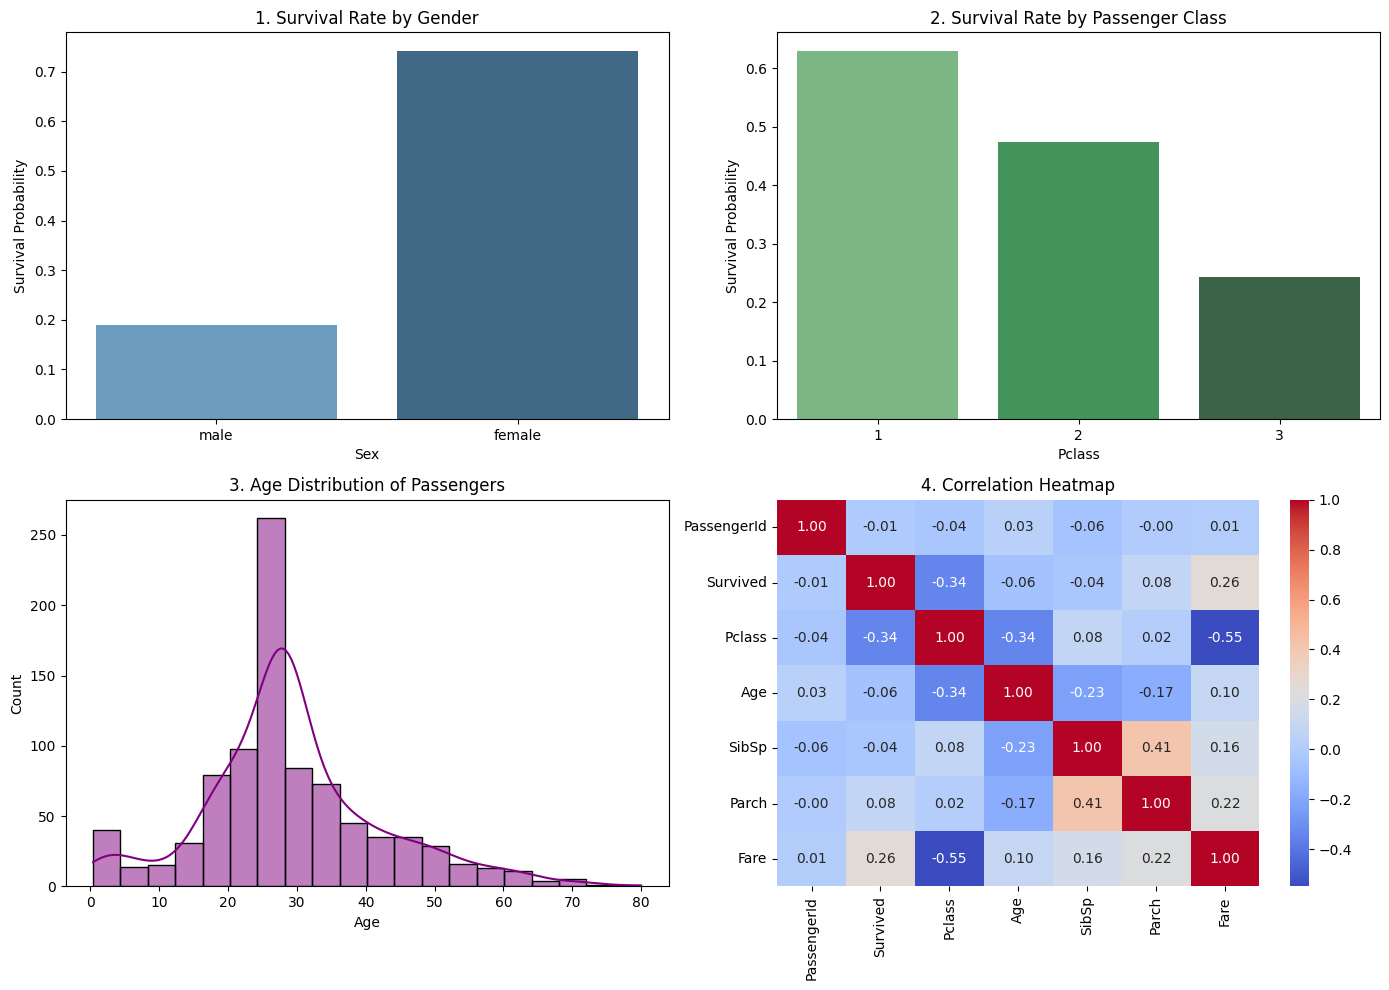

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Dataset direct load karein
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Pehle 5 rows dekhein
df.head()


# Missing values count karein
print("Dataset Shape:", df.shape)
print("\nHar column me missing values:")
print(df.isnull().sum())

# 1. Age ki missing values ko median age se fill karein
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Embarked ki missing values ko most frequent (mode) station se fill karein
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Cabin me lagbhag 77% data missing hai, isliye is pure column ko drop karte hain
df = df.drop(columns=['Cabin'])

# Verify karein ki missing values bachi hain ya nahi
print("Clean hone ke baad missing values:")
print(df.isnull().sum())

# Plots ke liye figure create karein
plt.figure(figsize=(14, 10))

# Chart 1: Gender vs Survival Rate
plt.subplot(2, 2, 1)
sns.barplot(x="Sex", y="Survived", data=df, errorbar=None, palette="Blues_d")
plt.title("1. Survival Rate by Gender")
plt.ylabel("Survival Probability")

# Chart 2: Passenger Class vs Survival Rate
plt.subplot(2, 2, 2)
sns.barplot(x="Pclass", y="Survived", data=df, errorbar=None, palette="Greens_d")
plt.title("2. Survival Rate by Passenger Class")
plt.ylabel("Survival Probability")

# Chart 3: Age Distribution (Kaunsi age ke log zyada the)
plt.subplot(2, 2, 3)
sns.histplot(df["Age"], bins=20, kde=True, color="purple")
plt.title("3. Age Distribution of Passengers")
plt.xlabel("Age")

# Chart 4: Correlation Heatmap (Numbers ke beech relation)
plt.subplot(2, 2, 4)
numeric_df = df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("4. Correlation Heatmap")

plt.tight_layout()
plt.show()